In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 0 = DEAD
# 1 = LIVES

In [2]:
df = pd.read_csv('train.csv')
df

,Patient_ID,Age,Marital_Status,Year of Operation,Positive_Axillary_Nodes,Tumor_Size,Radiation_Therapy,Chemotherapy,Hormone_Therapy,Survival_Status
0,1,77,Married,1962,5,3.0,No,Yes,No,1
1,2,36,Married,1964,2,1.9,Yes,No,No,1
2,3,47,Married,1960,5,2.0,No,No,No,0
3,4,54,Married,1965,0,1.4,No,No,No,0
4,5,35,Single,1968,5,4.1,Yes,Yes,Yes,1
...,...,...,...,...,...,...,...,...,...,...
1495,1496,39,Married,1967,1,3.8,Yes,Yes,No,1
1496,1497,66,Married,1966,8,2.8,No,No,No,1
1497,1498,73,Married,1963,4,3.5,Yes,No,No,0
1498,1499,66,Married,1963,0,0.7,Yes,No,Yes,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               1500 non-null   int64  
 1   Age                      1500 non-null   int64  
 2   Marital_Status           1500 non-null   object 
 3   Year of Operation        1500 non-null   int64  
 4   Positive_Axillary_Nodes  1500 non-null   int64  
 5   Tumor_Size               1500 non-null   float64
 6   Radiation_Therapy        1500 non-null   object 
 7   Chemotherapy             1500 non-null   object 
 8   Hormone_Therapy          1500 non-null   object 
 9   Survival_Status          1500 non-null   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 117.3+ KB


In [4]:
df.describe()

,Patient_ID,Age,Year of Operation,Positive_Axillary_Nodes,Tumor_Size,Survival_Status
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000
mean,750.500000,56.894000,1963.464667,9.76000,2.785800,0.493333
std,433.157015,15.435768,3.382166,10.32454,1.323994,0.500122
min,1.000000,30.000000,1958.000000,0.00000,0.500000,0.000000
25%,375.750000,44.000000,1961.000000,3.00000,1.700000,0.000000
50%,750.500000,57.000000,1963.000000,7.00000,2.800000,0.000000
75%,1125.250000,70.000000,1966.000000,13.00000,3.900000,1.000000
max,1500.000000,83.000000,1969.000000,52.00000,5.000000,1.000000


# Notes
- Some col must be coded
- 'Positive_Axillary_Nodes' = 0 is fine
- Visualiation is needed
- Discard 'Id'

# Dropping 'Id'

In [5]:
df = df.drop(columns= 'Patient_ID')

# Lowercassing the col names (is that a word??)

In [6]:
df.columns = df.columns.str.lower()

In [7]:
df.columns = df.columns.str.replace(' ', '_')

In [8]:
df.columns

Index(['age', 'marital_status', 'year_of_operation', 'positive_axillary_nodes',
       'tumor_size', 'radiation_therapy', 'chemotherapy', 'hormone_therapy',
       'survival_status'],
      dtype='object')

# EDA

survival_status
0    760
1    740
Name: count, dtype: int64

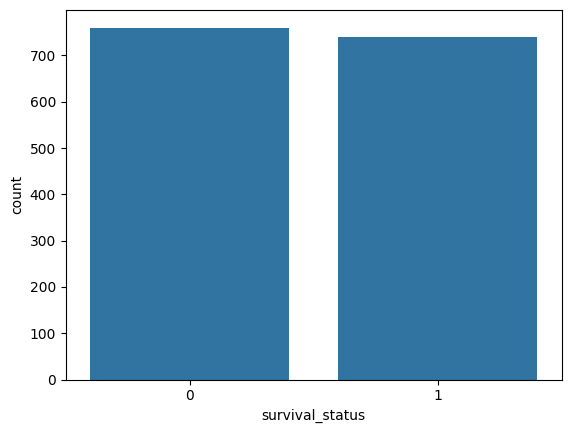

In [9]:
sns.countplot(x='survival_status',data = df)
df['survival_status'].value_counts()

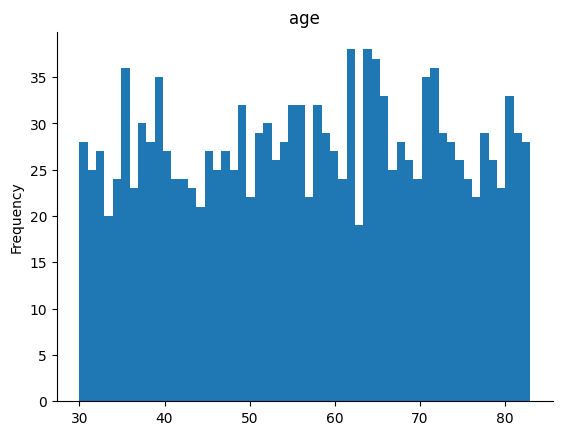

In [10]:
df['age'].plot(kind='hist', bins=54, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

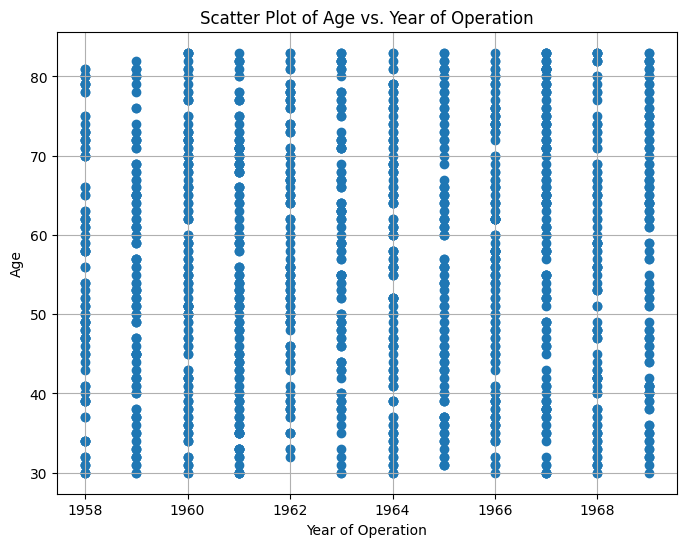

In [11]:
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['year_of_operation'], df['age'])
plt.title('Scatter Plot of Age vs. Year of Operation')
plt.xlabel('Year of Operation')
plt.ylabel('Age')
plt.grid(True)
plt.show()

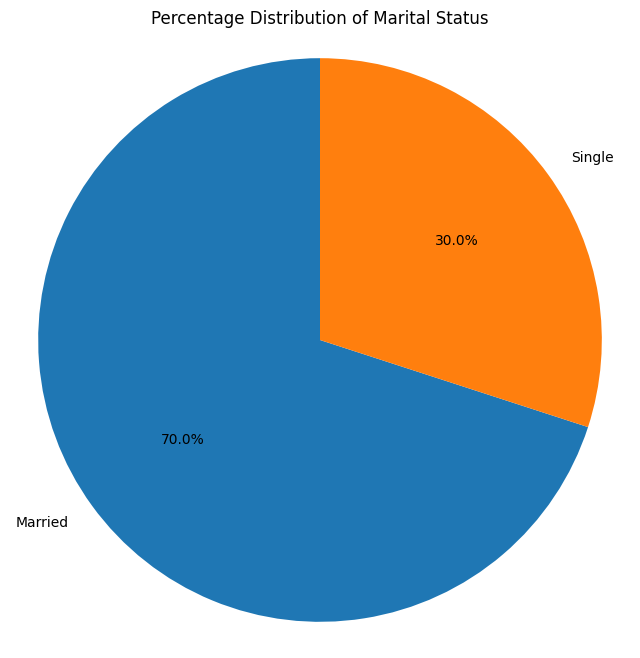

In [12]:
status_counts = df['marital_status'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage Distribution of Marital Status')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

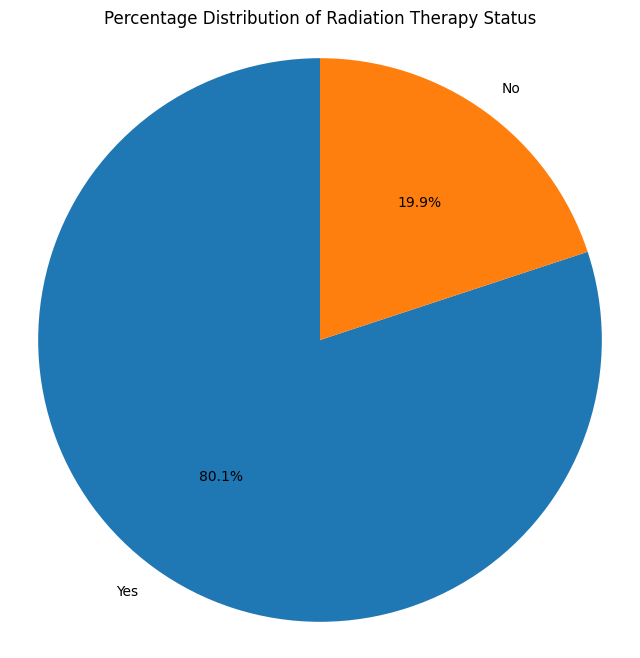

In [13]:
status_counts = df['radiation_therapy'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage Distribution of Radiation Therapy Status')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

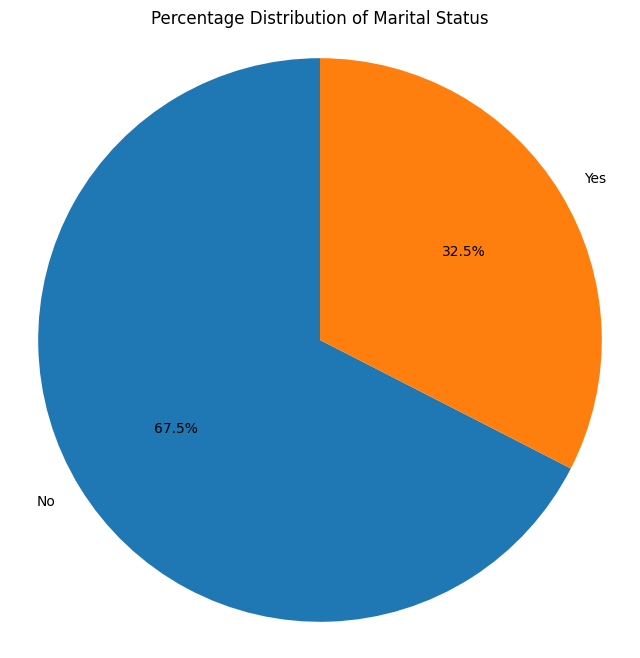

In [14]:
status_counts = df['chemotherapy'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage Distribution of Marital Status')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

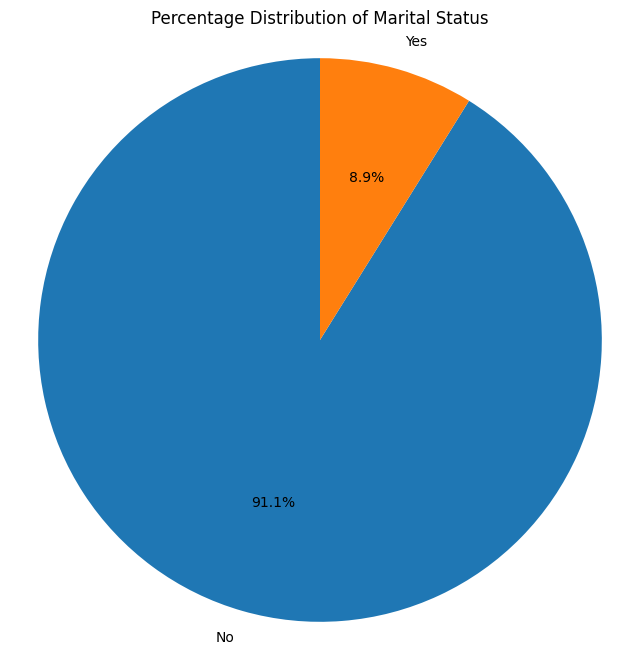

In [15]:
status_counts = df['hormone_therapy'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage Distribution of Marital Status')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

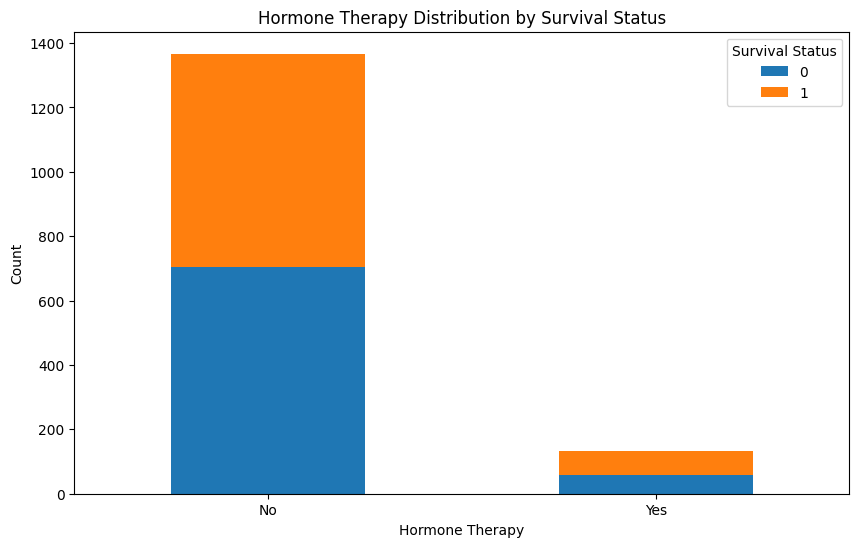

In [16]:
status_distribution = df.groupby([ 'hormone_therapy' , 'survival_status']).size().unstack()

# Plotting the distribution
status_distribution.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Hormone Therapy Distribution by Survival Status')
plt.xlabel('Hormone Therapy')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.legend(title='Survival Status')
plt.show()

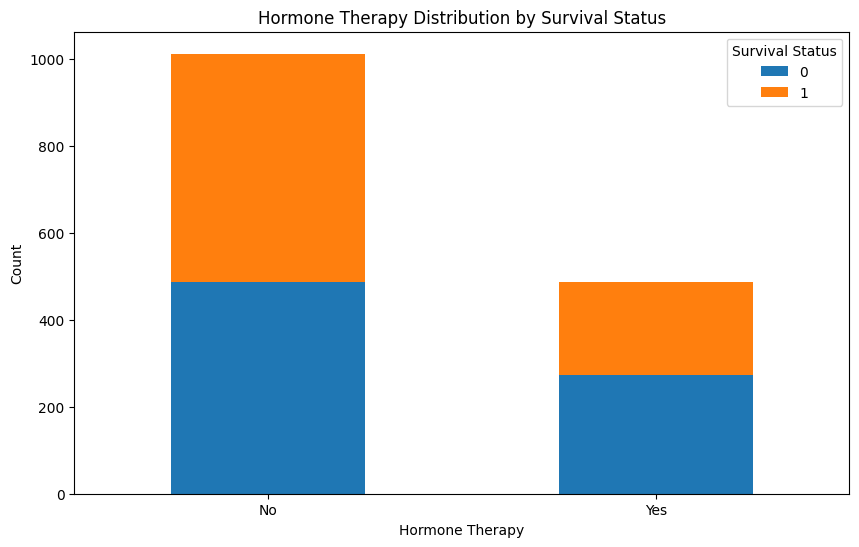

In [17]:
status_distribution = df.groupby([ 'chemotherapy' , 'survival_status']).size().unstack()

# Plotting the distribution
status_distribution.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Hormone Therapy Distribution by Survival Status')
plt.xlabel('Hormone Therapy')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.legend(title='Survival Status')
plt.show()

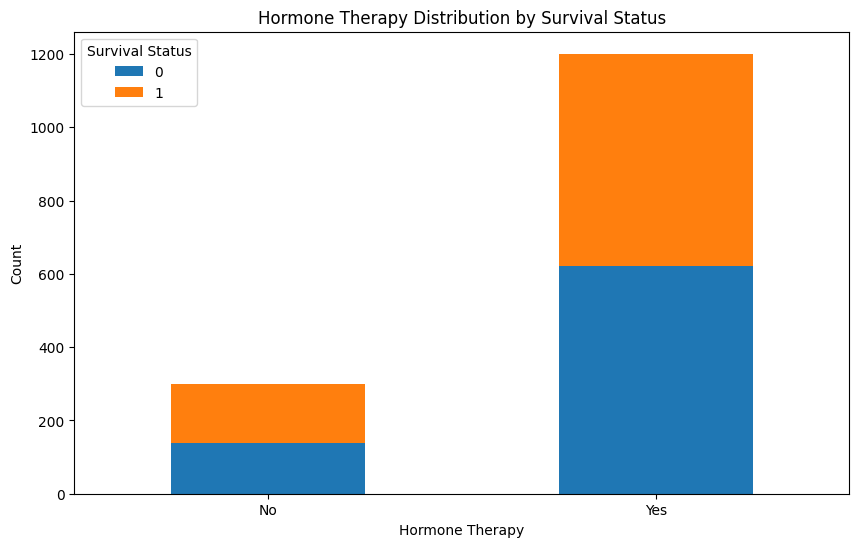

In [18]:
status_distribution = df.groupby([ 'radiation_therapy' , 'survival_status']).size().unstack()

# Plotting the distribution
status_distribution.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Hormone Therapy Distribution by Survival Status')
plt.xlabel('Hormone Therapy')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.legend(title='Survival Status')
plt.show()

### Encoding some data

In [19]:
df.head()

,age,marital_status,year_of_operation,positive_axillary_nodes,tumor_size,radiation_therapy,chemotherapy,hormone_therapy,survival_status
0,77,Married,1962,5,3.0,No,Yes,No,1
1,36,Married,1964,2,1.9,Yes,No,No,1
2,47,Married,1960,5,2.0,No,No,No,0
3,54,Married,1965,0,1.4,No,No,No,0
4,35,Single,1968,5,4.1,Yes,Yes,Yes,1


we will encode marital_status, radiation_therapy, chemotherapy, hormone_therapy into 0s and 1s

In [20]:
df["marital_status"].unique()

array(['Married', 'Single'], dtype=object)

In [21]:
df["radiation_therapy"].unique()

array(['No', 'Yes'], dtype=object)

In [22]:
df["chemotherapy"].unique()

array(['Yes', 'No'], dtype=object)

In [23]:
df["hormone_therapy"].unique()

array(['No', 'Yes'], dtype=object)

In [24]:
from sklearn.preprocessing import OrdinalEncoder 

In [25]:
enc = OrdinalEncoder()

In [26]:
columns_to_encode = ["marital_status", "radiation_therapy", "chemotherapy", "hormone_therapy"]

for column in columns_to_encode:
    df[column] = enc.fit_transform(df[[column]])

In [27]:
df.head()

,age,marital_status,year_of_operation,positive_axillary_nodes,tumor_size,radiation_therapy,chemotherapy,hormone_therapy,survival_status
0,77,0.0,1962,5,3.0,0.0,1.0,0.0,1
1,36,0.0,1964,2,1.9,1.0,0.0,0.0,1
2,47,0.0,1960,5,2.0,0.0,0.0,0.0,0
3,54,0.0,1965,0,1.4,0.0,0.0,0.0,0
4,35,1.0,1968,5,4.1,1.0,1.0,1.0,1


## Training

Due to the problem being a supervised classification problem, these will be the models we are going to compar to each other for now:
- Logistic Regression
- Super Vector Machine
- K-Nearest Neighbors
- Decison Tree
- Random Forest
- Naive Bayes
- XGBoost
- LightGBM


In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
from sklearn.metrics import f1_score, recall_score, precision_score

In [35]:
X = df.drop(columns=['survival_status'])
y = df['survival_status']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Preparing the Models/ Score lists

In [54]:
models = [LogisticRegression(random_state=42),
          KNeighborsClassifier(),
          SVC(probability=True,random_state=42),
          GaussianNB(),
          DecisionTreeClassifier(random_state=42),
          RandomForestClassifier(random_state=42),
          xgb.XGBClassifier(),
          lgb.LGBMClassifier(),]
model_names = ['LogisticRegression','KNN','SVM','NaiveBayes','DecisionTree','RandomForest','XGBoost','LightGBM']

In [38]:
f1_scores = []
recall = []
precision = []

## Training the Models

In [55]:
for model, name in zip(models, model_names):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    r = recall_score(y_test,y_pred)
    p = precision_score(y_test,y_pred)
    f1_scores.append(f1)
    recall.append(r)
    precision.append(p)
    print('%s: F1-score = %0.3f' % (name, f1))
    print('%s: Precision = %0.3f' % (name, p))
    print('%s: Recall = %0.3f' % (name, r))
    print('\n')

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression: F1-score = 0.502
LogisticRegression: Precision = 0.552
LogisticRegression: Recall = 0.461


KNN: F1-score = 0.494
KNN: Precision = 0.527
KNN: Recall = 0.466




C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SVM: F1-score = 0.000
SVM: Precision = 0.000
SVM: Recall = 0.000


NaiveBayes: F1-score = 0.368
NaiveBayes: Precision = 0.552
NaiveBayes: Recall = 0.276


DecisionTree: F1-score = 0.508
DecisionTree: Precision = 0.520
DecisionTree: Recall = 0.496


RandomForest: F1-score = 0.474
RandomForest: Precision = 0.515
RandomForest: Recall = 0.440


XGBoost: F1-score = 0.501
XGBoost: Precision = 0.521
XGBoost: Recall = 0.483


[LightGBM] [Info] Number of positive: 508, number of negative: 542
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 165
[LightGBM] [Info] Number of data points in the train set: 1050, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.483810 -> initscore=-0.064785
[LightGBM] [Info] Start training from score -0.064785
LightGBM: F1-score = 0.488


## Setting up KNN

In [40]:
dt = DecisionTreeClassifier(random_state=42)

In [41]:
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [42]:
f1_dt = f1_score(y_test, y_pred_dt)
r_dt = recall_score(y_test, y_pred_dt)
p_dt = precision_score(y_test, y_pred_dt)


In [43]:
print('dt: F1-score = %0.3f' % (f1_dt))
print('dt: Precision = %0.3f' % (p_dt))
print('dt: Recall = %0.3f' % (r_dt))

dt: F1-score = 0.508
dt: Precision = 0.520
dt: Recall = 0.496


## TUNING THE DECISION TREE

In [59]:
from scipy.stats import randint
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

In [60]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [135]:
#setup the parameters
param_dict = {"max_depth" : [3,None],
            "min_samples_leaf" : randint(1,9),
            "criterion" : ["gini","entropy"]
}

In [136]:
tree = DecisionTreeClassifier()

In [137]:
tree_cv = RandomizedSearchCV(tree,param_dict,cv=7)

In [138]:
tree_cv.fit(X_train, y_train)

RandomizedSearchCV(cv=7, estimator=DecisionTreeClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, None],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000016D6EC0AF20>})

In [141]:
print("Tuned Decision Tree parameters : {}".format(tree_cv.best_params_))
print("best score is : {}".format(tree_cv.best_score_))

Tuned Decision Tree parameters : {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1}
best score is : 0.5323809523809524


## Setting up the Test Data

In [44]:
test = pd.read_csv('test.csv')
test

,Patient_ID,Age,Marital_Status,Year of Operation,Positive_Axillary_Nodes,Tumor_Size,Radiation_Therapy,Chemotherapy,Hormone_Therapy
0,1501,62,Single,1966,4,1.4,Yes,No,No
1,1502,33,Married,1960,4,3.8,Yes,No,No
2,1503,52,Married,1963,7,2.1,Yes,No,No
3,1504,56,Married,1968,7,1.6,Yes,No,No
4,1505,70,Married,1968,1,4.1,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...
495,1996,50,Single,1967,4,3.2,Yes,No,No
496,1997,53,Married,1961,3,3.0,Yes,No,No
497,1998,74,Married,1963,11,4.1,Yes,No,No
498,1999,37,Single,1960,23,4.4,No,No,Yes


In [45]:
test.columns = test.columns.str.replace(' ', '_')
test.columns = test.columns.str.lower()

In [46]:
columns_to_encode = ["marital_status", "radiation_therapy", "chemotherapy", "hormone_therapy"]

for column in columns_to_encode:
    test[column] = enc.fit_transform(test[[column]])

In [47]:
predictions = dt.predict(test.drop(columns=['patient_id']))

In [48]:
submission = pd.DataFrame({'id': test['patient_id'], 'survival_status': predictions})

In [49]:
submission.rename(columns={'id': 'Patient_ID'}, inplace=True)

In [50]:
submission.rename(columns={'survival_status': 'Survival_Status'}, inplace=True)

In [51]:
submission

,Patient_ID,Survival_Status
0,1501,1
1,1502,0
2,1503,1
3,1504,1
4,1505,0
...,...,...
495,1996,0
496,1997,0
497,1998,1
498,1999,1


## The Final Submission

In [52]:
submission.to_csv('sample_submission.csv', index=False)